In [0]:
%pip install prophet
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Shape      : (61, 4)
Date range : 2021-07-01 → 2026-07-01

Missing values:
month_start_date    0
year_month          0
order_count         0
total_quantity      0
dtype: int64

Summary statistics:


order_count,total_quantity
61.0,61.0
168.0,2152493.0
32.0,498642.0
114.0,1103059.0
144.0,1784371.0
165.0,2138603.0
200.0,2668178.0
229.0,2998113.0


Feature,Type,Role
month_start_date,Date (time index),Time index
year_month,String ordinal,Derived identifier
order_count,Numeric integer,Forecast target (primary)
total_quantity,Numeric integer,Numeric feature


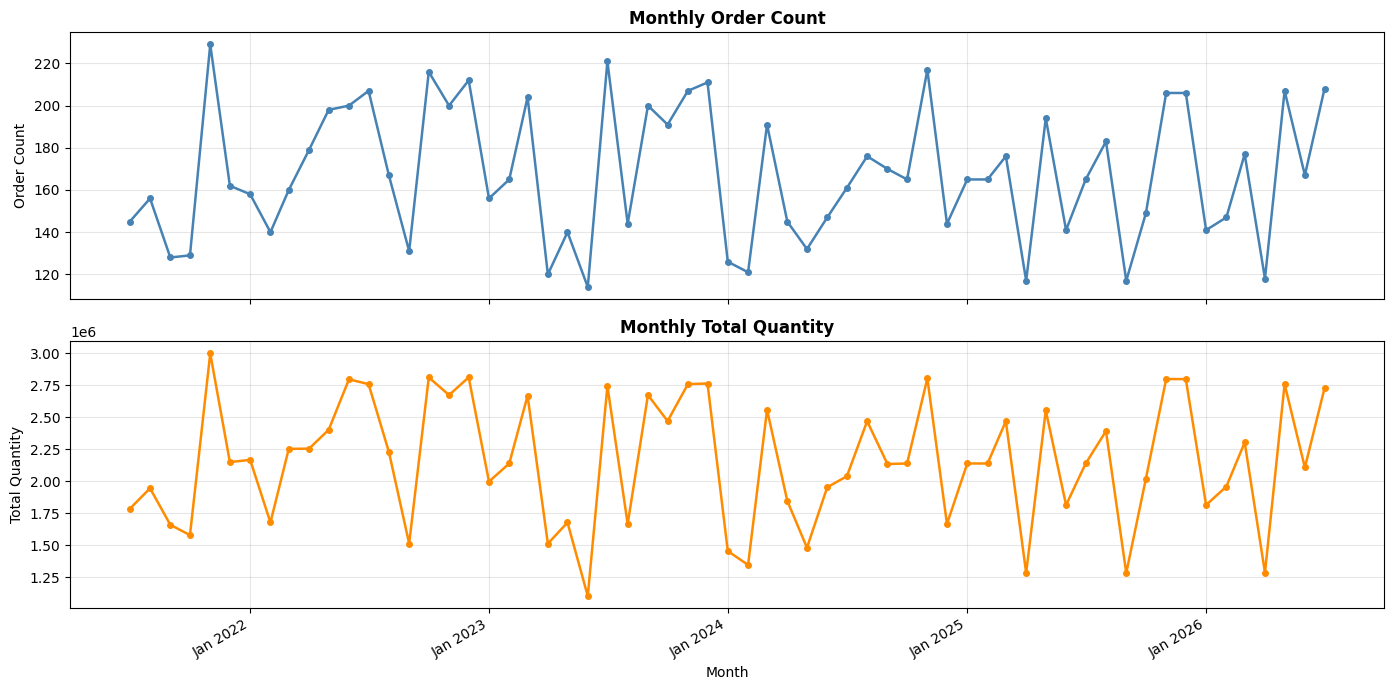

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data from Unity Catalog table
df = spark.table("jm_databricks_learning_ws.serve.sales_trend_monthly").toPandas()
df = df.sort_values("month_start_date").reset_index(drop=True)
df["month_start_date"] = pd.to_datetime(df["month_start_date"])

print(f"Shape      : {df.shape}")
print(f"Date range : {df['month_start_date'].min().date()} \u2192 {df['month_start_date'].max().date()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Summary statistics
print("\nSummary statistics:")
display(df[["order_count", "total_quantity"]].describe().round(0))

# Feature type table
feature_info = pd.DataFrame({
    "Feature": ["month_start_date", "year_month", "order_count", "total_quantity"],
    "Type":    ["Date (time index)", "String ordinal", "Numeric integer", "Numeric integer"],
    "Role":    ["Time index", "Derived identifier", "Forecast target (primary)", "Numeric feature"]
})
display(feature_info)

# Time series visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["month_start_date"], df["order_count"],
             marker="o", ms=4, linewidth=1.8, color="steelblue")
axes[0].set_title("Monthly Order Count", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Order Count")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["month_start_date"], df["total_quantity"],
             marker="o", ms=4, linewidth=1.8, color="darkorange")
axes[1].set_title("Monthly Total Quantity", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Quantity")
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

In [0]:
from prophet import Prophet
import mlflow
import numpy as np

# Set MLflow experiment
mlflow.set_experiment("/Users/yogirajsinh.parmar@jayseaflux.onmicrosoft.com/Sales_Forecast_Prophet")

# Prepare Prophet-format dataframe (ds = date, y = target)
prophet_df = df[["month_start_date", "order_count"]].rename(
    columns={"month_start_date": "ds", "order_count": "y"})

# Train / test split — hold out last 6 months for evaluation
N_TEST = 6
train_df = prophet_df.iloc[:-N_TEST].copy()
test_df  = prophet_df.iloc[-N_TEST:].copy()
print(f"Training samples : {len(train_df)}  |  Test samples : {N_TEST}")
print(f"Train period : {train_df['ds'].min().date()} \u2192 {train_df['ds'].max().date()}")
print(f"Test period  : {test_df['ds'].min().date()} \u2192 {test_df['ds'].max().date()}")

# Model hyperparameters
params = {
    "seasonality_mode":        "multiplicative",
    "yearly_seasonality":      True,
    "weekly_seasonality":      False,
    "daily_seasonality":       False,
    "changepoint_prior_scale": 0.1,
    "seasonality_prior_scale": 10.0,
}

with mlflow.start_run(run_name="prophet_order_count") as run:
    mlflow.log_params(params)
    mlflow.log_params({"train_size": len(train_df), "test_size": N_TEST, "target": "order_count"})

    # Train model on training data
    model = Prophet(**params)
    model.fit(train_df)

    # Predict over the test window
    future_test = model.make_future_dataframe(periods=N_TEST, freq="MS")
    forecast_cv = model.predict(future_test)

    # Align predictions with test actuals
    preds   = forecast_cv.set_index("ds")["yhat"].reindex(test_df["ds"].values)
    actuals = test_df.set_index("ds")["y"]

    mae  = float(np.mean(np.abs(actuals - preds)))
    rmse = float(np.sqrt(np.mean((actuals - preds) ** 2)))
    mape = float(np.mean(np.abs((actuals - preds) / actuals)) * 100)

    mlflow.log_metrics({"test_mae": mae, "test_rmse": rmse, "test_mape": mape})

    print(f"\nEvaluation on last {N_TEST} months:")
    print(f"  MAE  : {mae:.1f} orders")
    print(f"  RMSE : {rmse:.1f} orders")
    print(f"  MAPE : {mape:.1f}%")
    print(f"\nMLflow run  : {run.info.run_id}")

    # Actual vs predicted comparison
    comparison = test_df.copy().rename(columns={"y": "actual"})
    comparison["predicted"] = preds.values
    comparison["error"]     = (comparison["actual"] - comparison["predicted"]).round(1)
    comparison["ds"]        = comparison["ds"].dt.strftime("%Y-%m")
    comparison[["predicted", "error"]] = comparison[["predicted", "error"]].round(1)
    display(comparison.reset_index(drop=True))

2026/07/09 11:42:30 INFO mlflow.tracking.fluent: Experiment with name '/Users/yogirajsinh.parmar@jayseaflux.onmicrosoft.com/Sales_Forecast_Prophet' does not exist. Creating a new experiment.


Training samples : 55  |  Test samples : 6
Train period : 2021-07-01 → 2026-01-01
Test period  : 2026-02-01 → 2026-07-01


11:42:32 - cmdstanpy - INFO - Chain [1] start processing
11:42:32 - cmdstanpy - INFO - Chain [1] done processing



Evaluation on last 6 months:
  MAE  : 19.4 orders
  RMSE : 24.3 orders
  MAPE : 11.1%

MLflow run  : e4bfa126176941c89ac885df611cfca9


ds,actual,predicted,error
2026-02,147,147.5,-0.5
2026-03,177,180.9,-3.9
2026-04,118,137.0,-19.0
2026-05,207,162.2,44.8
2026-06,167,142.0,25.0
2026-07,208,184.9,23.1


11:42:37 - cmdstanpy - INFO - Chain [1] start processing
11:42:37 - cmdstanpy - INFO - Chain [1] done processing


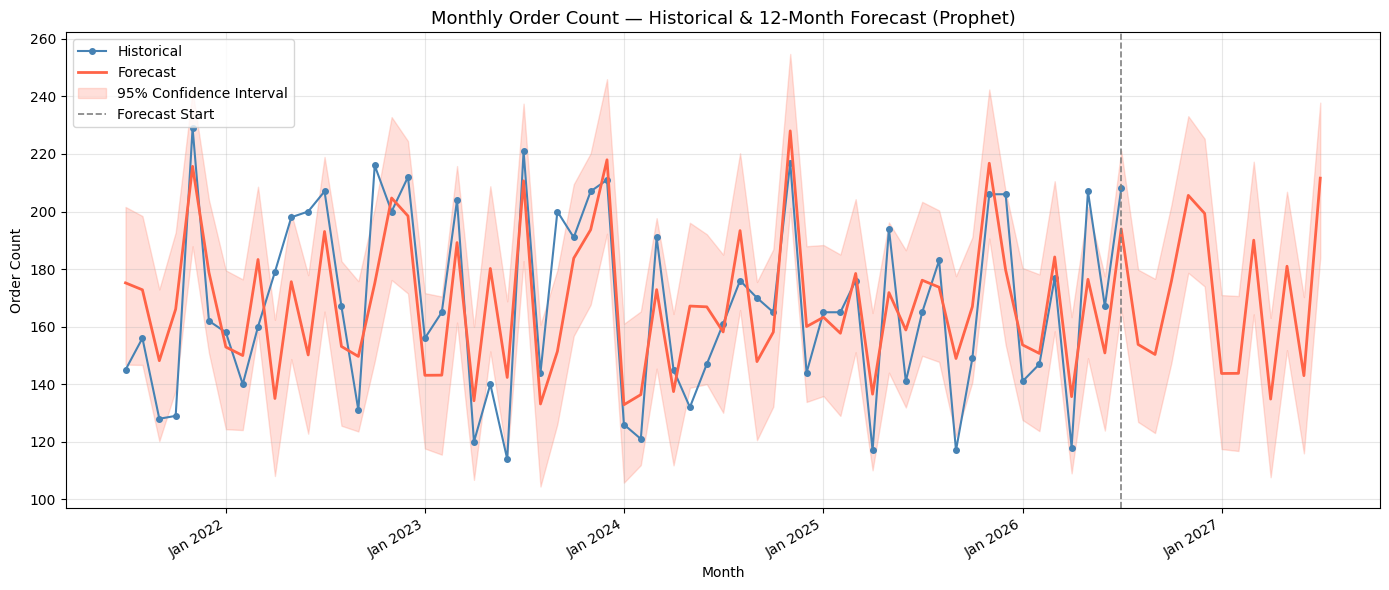

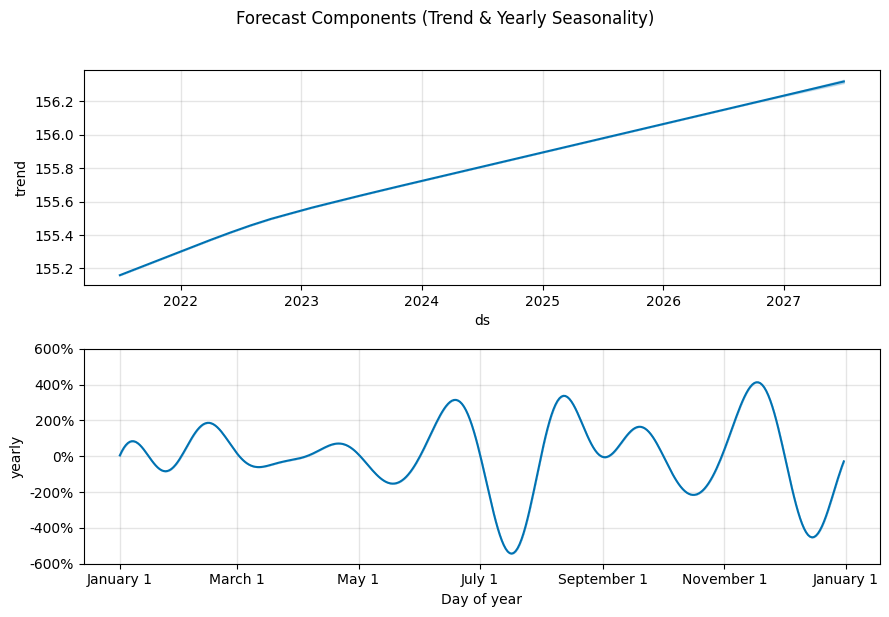

Month,Forecast (orders),Lower Bound,Upper Bound
2026-08,154,127,180
2026-09,150,123,177
2026-10,176,147,202
2026-11,206,179,233
2026-12,199,174,225
2027-01,144,117,171
2027-02,144,117,171
2027-03,190,164,217
2027-04,135,108,163
2027-05,181,152,207


In [0]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Retrain Prophet on full dataset and project 12 months ahead
model_full = Prophet(**params)
model_full.fit(prophet_df)

future   = model_full.make_future_dataframe(periods=12, freq="MS")
forecast = model_full.predict(future)
cutoff   = prophet_df["ds"].max()

# --- Plot 1: Historical + 12-month forecast ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prophet_df["ds"], prophet_df["y"],
        label="Historical", color="steelblue", marker="o", ms=4, linewidth=1.5)
ax.plot(forecast["ds"], forecast["yhat"],
        label="Forecast", color="tomato", linewidth=2)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                alpha=0.2, color="tomato", label="95% Confidence Interval")
ax.axvline(cutoff, linestyle="--", color="gray", linewidth=1.2, label="Forecast Start")
ax.set_title("Monthly Order Count \u2014 Historical & 12-Month Forecast (Prophet)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Order Count")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

# --- Plot 2: Trend and seasonality components ---
fig2 = model_full.plot_components(forecast)
plt.suptitle("Forecast Components (Trend & Yearly Seasonality)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# --- Next 12 months forecast table ---
next12 = forecast[forecast["ds"] > cutoff][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
next12.columns = ["Month", "Forecast (orders)", "Lower Bound", "Upper Bound"]
next12["Month"] = next12["Month"].dt.strftime("%Y-%m")
next12[["Forecast (orders)", "Lower Bound", "Upper Bound"]] = (
    next12[["Forecast (orders)", "Lower Bound", "Upper Bound"]].round(0).astype(int)
)
display(next12.reset_index(drop=True))